# Credit Card Fraud Detection: Exploratory Data Analysis
Name: Lehlogonolo Shika  |  Dataset: Kaggle Credit Card Fraud (284,807 rows)  |  Tools: Python, Pandas, NumPy, Matplotlib, Seaborn
**Objective:** Analyse the structure, distributions, class balance, outliers, and feature correlations of a real-world fraud dataset to inform preprocessing decisions for machine learning.

# Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load and Inspect the Data
Load the dataset and examine its shape, column names, and data types before any analysis.

In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Users\dikel\Videos\EDA Project\creditcard.csv")

# First look 
print(df.shape) # rows and columns 
print(df.head())# First 5 rows
print(df.tail()) # Last 5 rows
print(df.dtypes) # The data types of each columns
print(df.columns.tolist()) # Column names 

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

284,807 rows × 31 columns. All columns are float64 except Class (int64). V1-V28 are PCA-anonymized features. Time = seconds elapsed, Amount = transaction value, Class = fraud label.
Finding: No type conversion needed

## Step 2: Missing Values and Duplicates
Check data completeness and remove duplicate rows before analysis.

In [3]:
# Check for missing values 
print(df.isnull().sum()) # count of missing values per column
print("=" * 45)
print(df.isnull().sum().sum()) #Total missing values in the whole dataset

# Check for duplicate rows 
print("=" * 45)
print(df.duplicated().sum()) # Number of duplicate rows

# Basic stats summary
print("=" * 45)
print(df.describe()) # Min, Max, Mean, STD for every column 


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
0
1081
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01

Zero missing values. Amount ranges from 0 to 25,691 - heavily right-skewed. V1-V28 means near 0 confirming prior PCA scaling.
Finding: Amount requires log transformation

In [4]:
# Drop duplicates 
df = df.drop_duplicates()
print("Shape:", df.shape)

Shape: (283726, 31)


 Removed 1,081 duplicate rows.

## Step 3: Distributions
Plot raw Amount vs log-transformed Amount and Time distribution.
Finding: Log1p(Amount) normalises skew. Time shows a clear 2-day pattern.

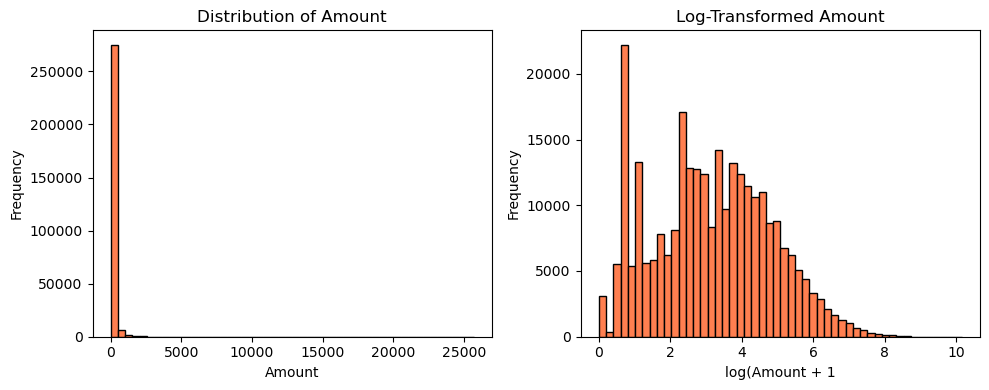

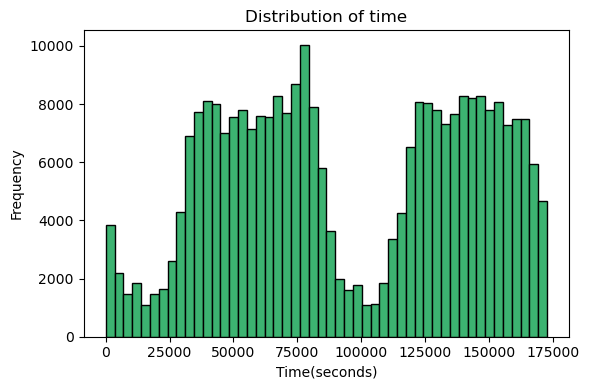

In [5]:
# Distribution of amount 
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df["Amount"], bins=50, color= "coral", edgecolor ="black")
plt.title("Distribution of Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

# Log  Transformation 
plt.subplot(1, 2,2)
plt.hist(df["Amount"].apply(lambda x:np.log1p(x)), bins=50, color="coral", edgecolor="black")
plt.title("Log-Transformed Amount")
plt.xlabel("log(Amount + 1")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#Distribution of time
plt.figure(figsize=(6, 4))
plt.hist(df["Time"], bins=50, color="mediumseagreen",  edgecolor="black")
plt.title("Distribution of time")
plt.xlabel("Time(seconds)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Step 4: Class Imbalance
Quantify and visualise the fraud vs non-fraud split. Compare Amount distributions per class.
Finding: 492 fraud (0.17%) vs 284,315 normal (99.83%). SMOTE justified.

Class
0    283253
1       473
Name: count, dtype: int64

Class
0    99.83
1     0.17
Name: proportion, dtype: float64


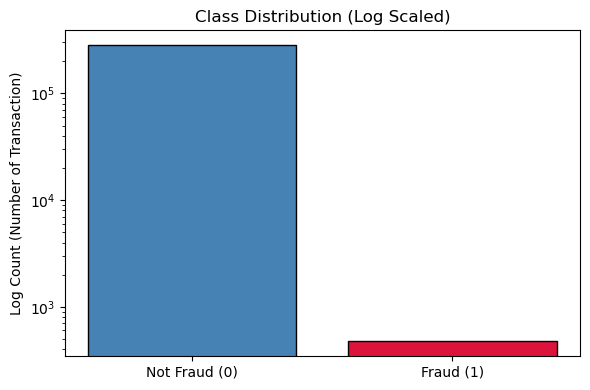

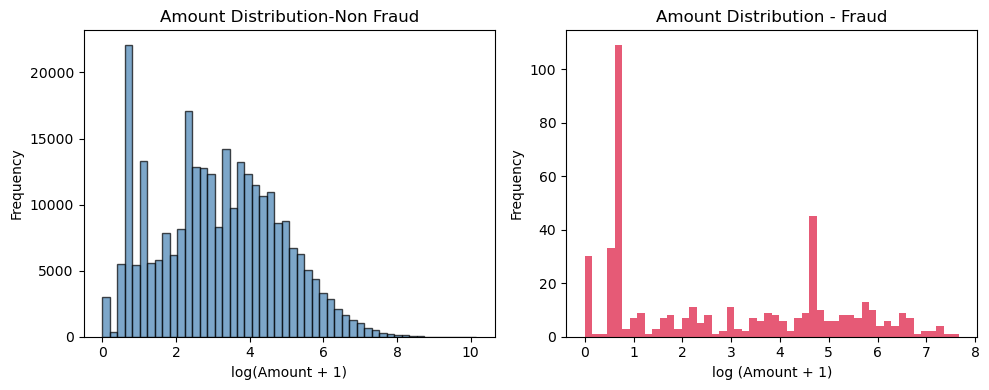

In [6]:
# Count each class
class_counts = df["Class"].value_counts()
print(class_counts)
print()

# Percentage Breakdown 
class_pct = df["Class"].value_counts(normalize=True) * 100
print(class_pct.round(2))

# Bar Chart 
plt.figure(figsize=(6, 4))
plt.bar(["Not Fraud (0)", "Fraud (1)"], class_counts.values, color=["steelblue", "crimson"], edgecolor="black")
plt.yscale("log")
plt.title("Class Distribution (Log Scaled)")
plt.ylabel("Log Count (Number of Transaction)")
plt.tight_layout()
plt.show()

# Compare Amount between fraud and non-fraud
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df[df["Class"]==0]["Amount"].apply(lambda x: np.log1p(x)), bins=50, color="steelblue", edgecolor="black", alpha=0.7)
plt.title("Amount Distribution-Non Fraud")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df[df["Class"]==1]["Amount"].apply(lambda x:np.log1p(x)), bins=50, color="crimson", alpha=0.7)
plt.title("Amount Distribution - Fraud")
plt.xlabel("log (Amount + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()




## Step 5: Outlier Detection
Apply IQR method to Amount. Split outliers by class before deciding on treatment.
Finding: 87 fraud cases are outliers. Do not remove. Use log transformation instead.


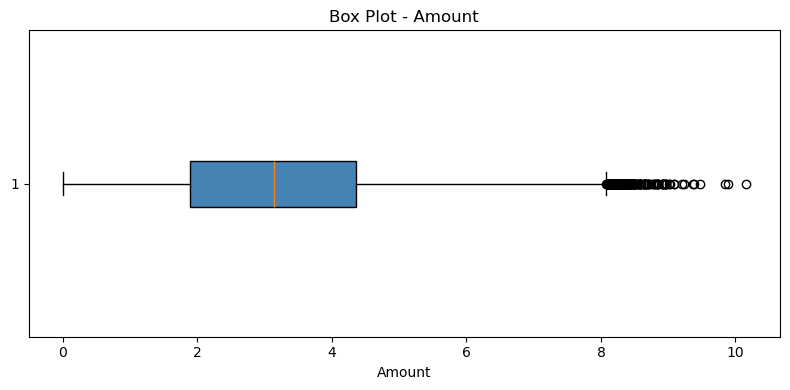

<Figure size 100000x40000 with 0 Axes>

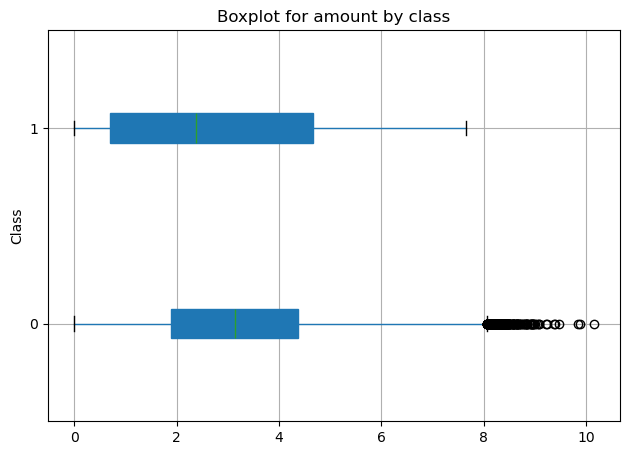

lower bound: -102.27
upper bound: 185.38
Number of outliers in Amount: 31685
Outliers percentage: 11.17%
Class
0    31598
1       87
Name: count, dtype: int64


In [22]:
# Box plot for Amount 
plt.figure(figsize=(8, 4))
plt.boxplot(df["Amount"].apply(lambda x:np.log1p(x)), vert=False, patch_artist=True, boxprops=dict(facecolor="steelblue", color="black"))
plt.title("Box Plot - Amount")
plt.xlabel("Amount")
plt.tight_layout()
plt.show()

# Box plot for amount by class
plt.figure(figsize=(1000, 400))
df[["Amount", "Class"]].assign(Amount=np.log1p(df["Amount"])).boxplot(column="Amount", by="Class", vert=False, patch_artist=True)
plt.title("Boxplot for amount by class")
plt.suptitle("")
plt.tight_layout()
plt.show()

#IQR method to count outliers in Amount 
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Amount"] < lower) | (df["Amount"] > upper)]
print(f"lower bound: {lower:.2f}")
print(f"upper bound: {upper:.2f}")
print(f"Number of outliers in Amount: {len(outliers)}")
print(f"Outliers percentage: {len(outliers)/len(df)*100:.2f}%")

# Check how many are outliers are fraud vs non-fraud
print(outliers["Class"].value_counts())




## Step 6: Feature Correlations
Rank all features by correlation with Class. Plot heatmap of top 10 features.
Finding: V17, V14, V12 strongest negative. V11, V4 strongest positive. No inter-feature redundancy.

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Name: Class, dtype: float64


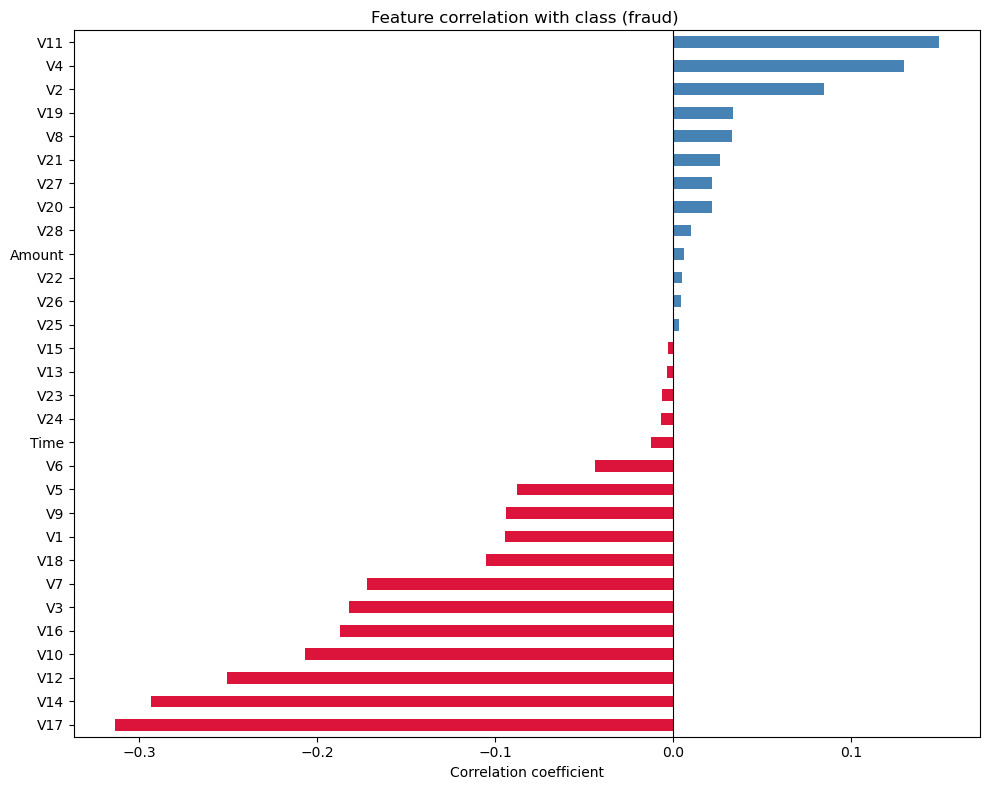

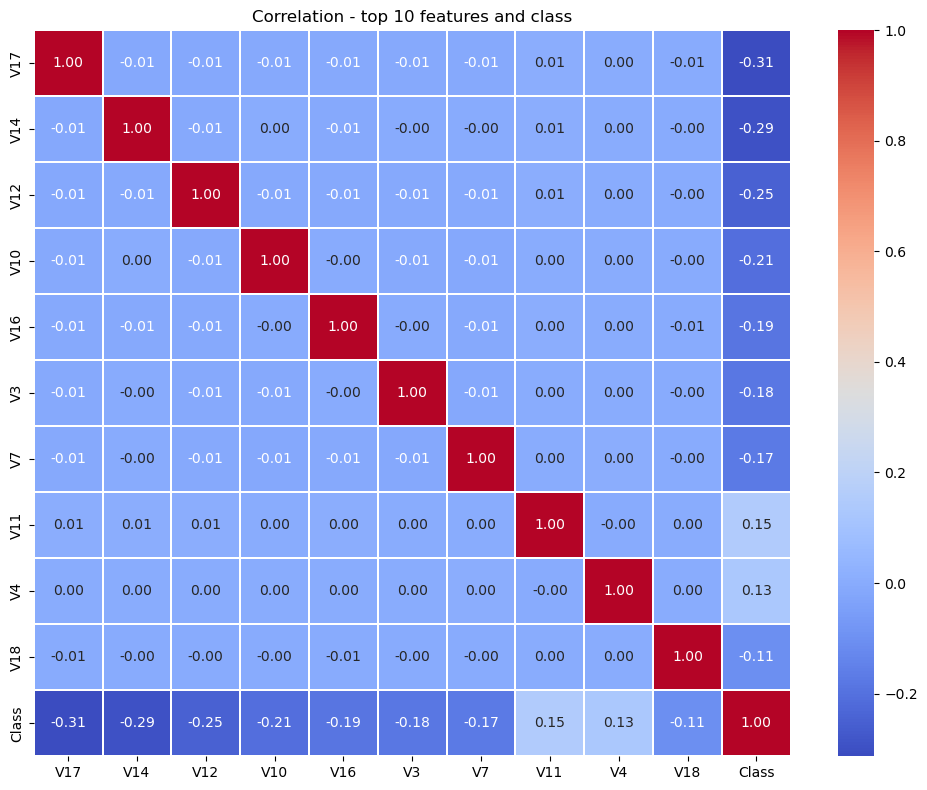

In [30]:
# Correlation of all feature with class 
corr_with_class = df.corr()["Class"].drop("Class").sort_values()
print(corr_with_class)

# Bar Chart of correlation with class
plt.figure(figsize=(10, 8))
corr_with_class.plot(kind="barh", color=["crimson" if x<0 else "steelblue" for x in corr_with_class])
plt.title("Feature correlation with class (fraud) ")
plt.xlabel("Correlation coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

# Heatmap with top correlated features 
top_features = corr_with_class.abs().sort_values(ascending=False).head(10).index.tolist()
top_features.append("Class")

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidth=0.05)
plt.title("Correlation - top 10 features and class")
plt.tight_layout()
plt.show()

## Key Findings and Preprocessing Decisions
1. No missing values. 1,081 duplicates removed.
2. Amount is heavily skewed. Apply log1p before modelling.
3. Time and Amount both need scaling. V1-V28 already scaled via PCA.
4. Severe class imbalance (0.17% fraud). Accuracy is a misleading metric. Use AUC-ROC and F1-score. Apply SMOTE.
5. 11.17% of Amount values are outliers but 87 are fraud cases. Preserve them.
6. Top predictors: V17, V14, V12 (negative), V11, V4 (positive).